In [1]:
import sys
import os

sys.path.append(os.path.abspath('../..'))

from technical_func import set_random_seed
from digits_rotate import build_rotating_eight_experiment
from model_autoencoder import AutoencoderSimple
from train_model import fit_model, get_data_loader
from visual_tools import visualize_latent_space
from data_file import TensorIndexDataset
import matplotlib.pyplot as plt
import numpy as np
import torch

device = "cuda:0"

c:\Users\sergey\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\sergey\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
if __name__ ==  "__main__":
    batch_size = 1000
    dataset, x_raw, info = build_rotating_eight_experiment(num_rotate=100)
    train_loader = get_data_loader(batch_size, dataset)

c:\Users\sergey\Documents\crs_lock\data_file.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.colors = torch.tensor(colors, dtype=torch.float32)


In [3]:
from experiments.digits_rotate.digits_rotate import build_rotated_digit_sequence_experiment

n_images = 100
dataset_, x_raw_, info_ = build_rotated_digit_sequence_experiment(
    digit=8, 
    num_rotate=n_images, 
    rotate_range=360.0,
    n_different=100
)
val_loader_ = get_data_loader(batch_size, dataset_, shuffle=False)


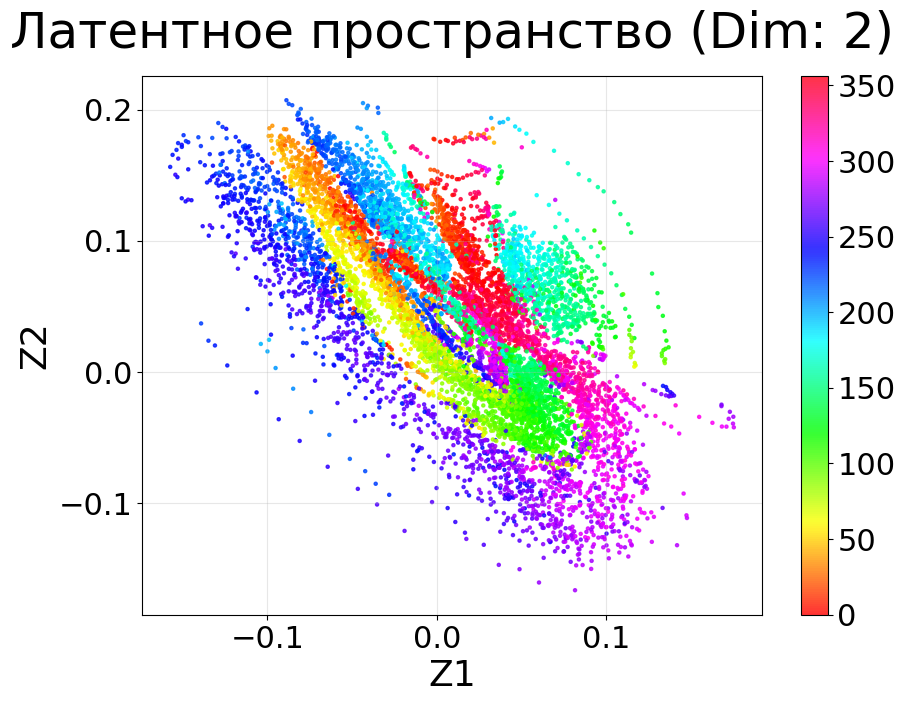

Train metrics: {'loss': 0.02884696051478386, 'rec_loss': 0.028197242133319377, 'enc_loss': 1.2994365260965423e-05, 'dec_loss': 0.0} cur epoch: 499


In [ ]:
set_random_seed(42)

student_high_reg = AutoencoderSimple(784, 784, 2).to(device)
teacher = AutoencoderSimple(784, 784, 2).to(device)
teacher.load_state_dict(student_high_reg.state_dict())
    
student_high_reg, _, _, _ = fit_model(student_high_reg, teacher, train_loader, epochs=500, reg_mode="encoder", n_points=3, radius_encoder=8, lambda_enc=50, verbose_latent=True, func_latent=visualize_latent_space, period=25)

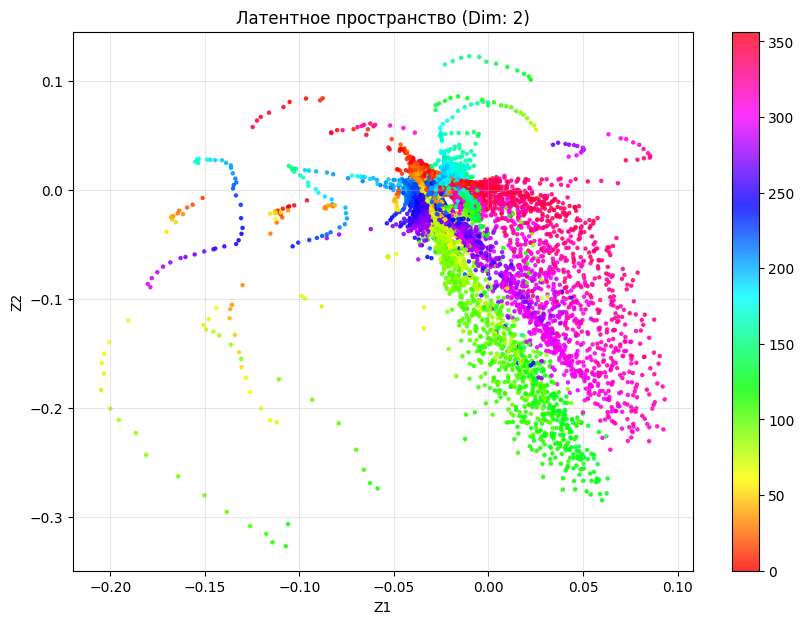

Train metrics: {'loss': 21331.605859375, 'rec_loss': 0.03414462432265282, 'enc_loss': 0.0, 'dec_loss': 0.021331571973860264} cur epoch: 499


In [45]:
set_random_seed(42)

student = AutoencoderSimple(784, 784, 2).to(device) 
teacher = AutoencoderSimple(784, 784, 2).to(device)
teacher.load_state_dict(student.state_dict())
    
student, teacher, _, _ = fit_model(student, teacher, train_loader, epochs=500, reg_mode="decoder", n_points=3, radius_decoder=0.1, lambda_dec=1e6, verbose_latent=True, func_latent=visualize_latent_space, period=250)

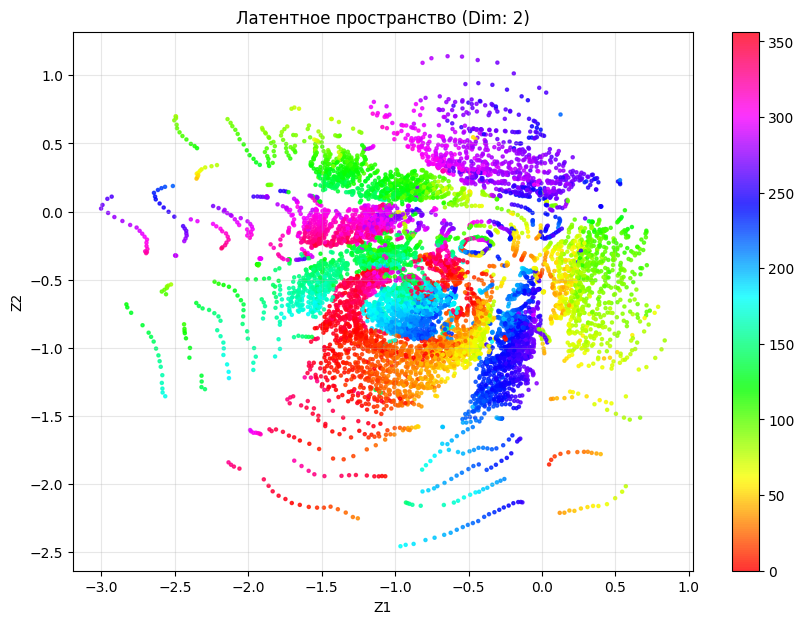

Train metrics: {'loss': 0.03899689316749573, 'rec_loss': 0.02374199703335762, 'enc_loss': 0.0, 'dec_loss': 0.015254895761609077} cur epoch: 499


In [14]:
set_random_seed(42)

student_low_reg_decoder2 = AutoencoderSimple(784, 784, 2).to(device)
teacher = AutoencoderSimple(784, 784, 2).to(device)
teacher.load_state_dict(student_low_reg_decoder2.state_dict())
    
student_low_reg_decoder2, _, _, _ = fit_model(student_low_reg_decoder2, teacher, train_loader, epochs=500, reg_mode="decoder", n_points=3, radius_decoder=0.1, lambda_dec=1e0, verbose_latent=True, func_latent=visualize_latent_space, period=25)

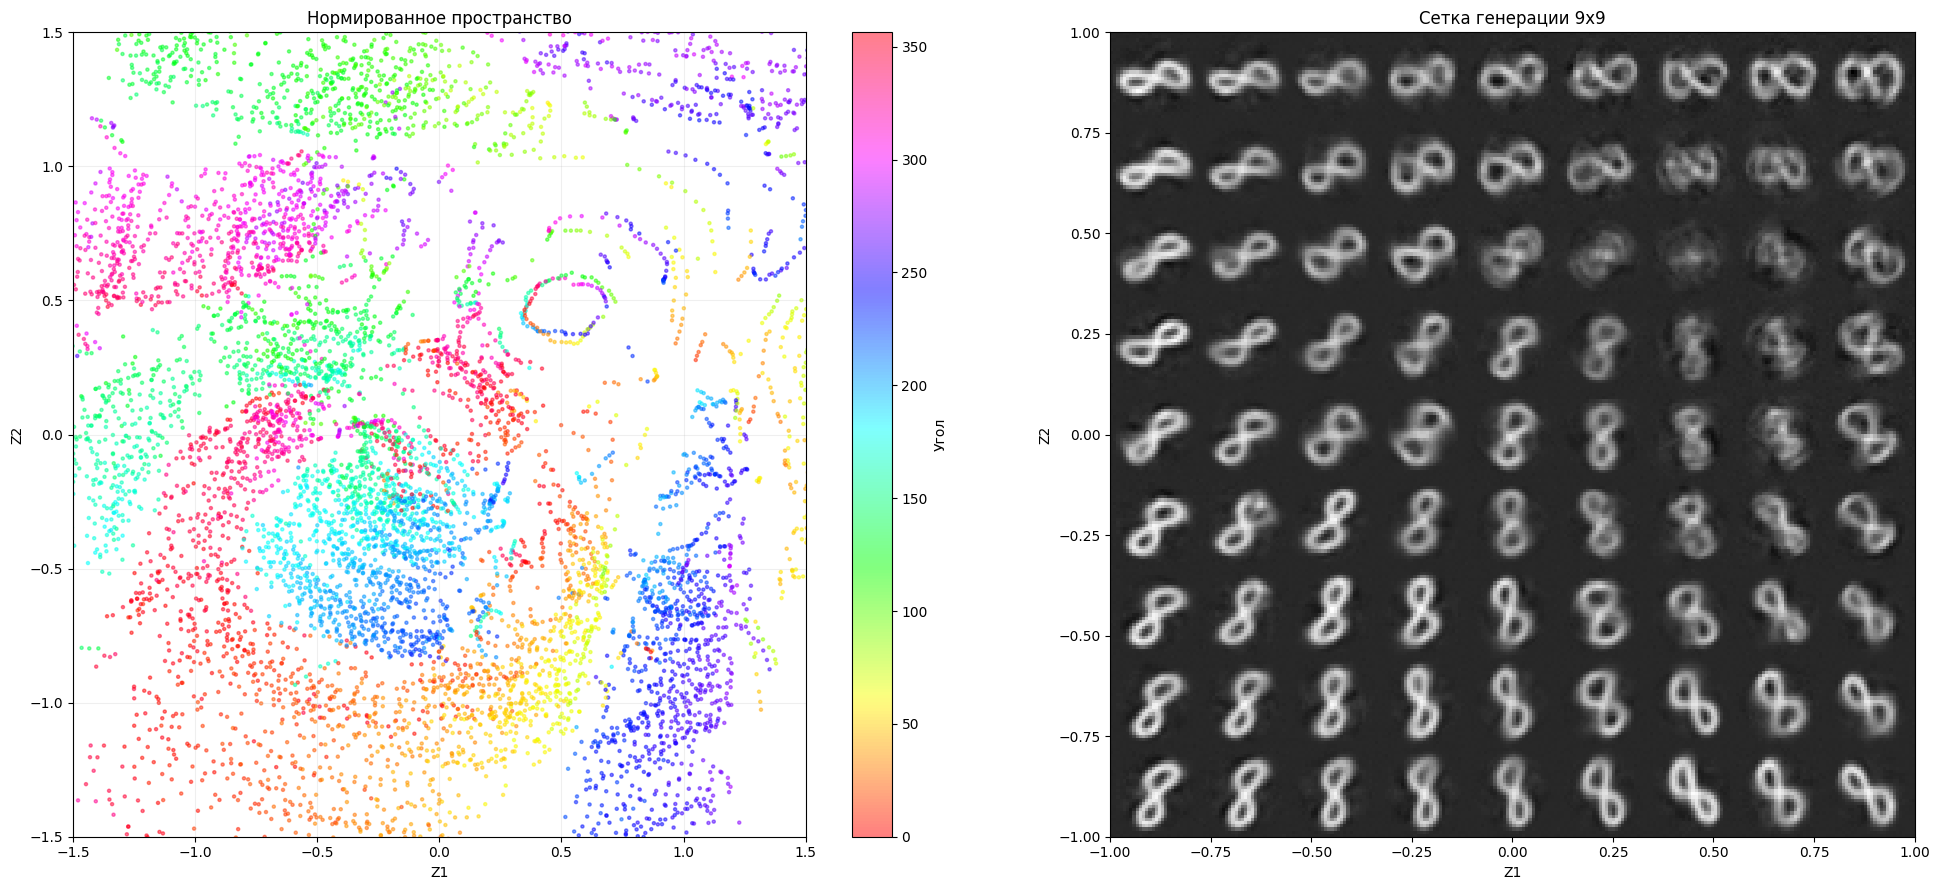

In [15]:
from visual_tools import visualize_std_analysis

visualize_std_analysis(student_low_reg_decoder2, train_loader, n=9)